In [1]:
from collections import defaultdict
from pathlib import Path
from typing import Iterable
import numpy as np
import pandas as pd

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib as mpl
import matplotlib.colors as colors
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [2]:
PROJ_DIR = Path.cwd().parent.parent
DATA_DIR = PROJ_DIR / 'data'
FIG_DIR = PROJ_DIR / 'figures'
fp = DATA_DIR / 'calhabmap_filtered_2024_20260128.csv'
assert fp.exists()

### ETL

* Load
* Quick look assess cleanup requirements
* Note columns of interest

In [3]:
df_raw = pd.read_csv(fp)

In [4]:
df_raw.head().T

,0,1,2,3,4
Location_Code,BBB,BBB,BBB,BBB,BBB
latitude (degrees_north),38.3126,38.3126,38.3126,38.3126,38.3126
longitude (degrees_east),-123.0825,-123.0825,-123.0825,-123.0825,-123.0825
depth (m),NaN,NaN,NaN,NaN,NaN
SampleID,BML Buoy,BML Buoy,BML Buoy,BML Buoy,BML Buoy
time (UTC),2024-03-18T19:50:00Z,2024-05-16T18:30:00Z,2024-08-28T21:19:00Z,2024-09-30T16:11:00Z,2025-01-17T18:37:00Z
Temp (degree_C),NaN,NaN,NaN,NaN,NaN
Air_Temp (degree_C),NaN,NaN,NaN,NaN,NaN
Salinity,NaN,NaN,NaN,NaN,NaN
Chl_Volume_Filtered (mL),NaN,NaN,NaN,NaN,NaN


In [5]:
df_raw.rename(columns={k:k.lower() for k in df_raw.columns}, inplace=True)

In [6]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 985 entries, 0 to 984
Data columns (total 41 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   location_code                                   985 non-null    object 
 1   latitude (degrees_north)                        985 non-null    float64
 2   longitude (degrees_east)                        985 non-null    float64
 3   depth (m)                                       427 non-null    float64
 4   sampleid                                        985 non-null    object 
 5   time (utc)                                      985 non-null    object 
 6   temp (degree_c)                                 886 non-null    float64
 7   air_temp (degree_c)                             92 non-null     float64
 8   salinity                                        142 non-null    float64
 9   chl_volume_filtered (ml)                   

In [7]:
CORE_RENAME = {
    "sampleid": "sample_id",
    "location_code": "site_code",
    "location_name": "site_name",
    "latitude (degrees_north)": "lat",
    "longitude (degrees_east)": "lon",
    "time (utc)": "time_utc"
}

ANCILLARY_COLS = [
    # ancillary
    "temp (degree_c)", "chl1 (mg/m3)", "chl2 (mg/m3)", "avg_chloro (mg/m3)",
]

CELL_COLS = [c for c in df_raw.columns if c.endswith("(cells/l)")]
KEEP_COLS = ANCILLARY_COLS + [v for v in CORE_RENAME.values()] + CELL_COLS

In [8]:
CELL_COLS

['akashiwo_sanguinea (cells/l)',
 'alexandrium_spp (cells/l)',
 'dinophysis_spp (cells/l)',
 'lingulodinium_polyedra (cells/l)',
 'prorocentrum_spp (cells/l)',
 'pseudo_nitzschia_delicatissima_group (cells/l)',
 'pseudo_nitzschia_seriata_group (cells/l)',
 'ceratium_spp (cells/l)',
 'cochlodinium_spp (cells/l)',
 'gymnodinium_spp (cells/l)',
 'other_diatoms (cells/l)',
 'other_dinoflagellates (cells/l)',
 'total_phytoplankton (cells/l)']

In [9]:
KEEP_COLS

['temp (degree_c)',
 'chl1 (mg/m3)',
 'chl2 (mg/m3)',
 'avg_chloro (mg/m3)',
 'sample_id',
 'site_code',
 'site_name',
 'lat',
 'lon',
 'time_utc',
 'akashiwo_sanguinea (cells/l)',
 'alexandrium_spp (cells/l)',
 'dinophysis_spp (cells/l)',
 'lingulodinium_polyedra (cells/l)',
 'prorocentrum_spp (cells/l)',
 'pseudo_nitzschia_delicatissima_group (cells/l)',
 'pseudo_nitzschia_seriata_group (cells/l)',
 'ceratium_spp (cells/l)',
 'cochlodinium_spp (cells/l)',
 'gymnodinium_spp (cells/l)',
 'other_diatoms (cells/l)',
 'other_dinoflagellates (cells/l)',
 'total_phytoplankton (cells/l)']

In [10]:
    # --- Standardize core columns
    df = df_raw.rename(columns=CORE_RENAME).copy()

In [11]:
df["time_utc"] = pd.to_datetime(df["time_utc"], errors="coerce", utc=True)


# Apply cutoff
cutoff = pd.Timestamp("2024-03-06", tz="UTC")
df = df[df["time_utc"] >= cutoff]

print("Rows after cutoff:", len(df))
print("Date range:", df["time_utc"].min(), "→", df["time_utc"].max())


Rows after cutoff: 985
Date range: 2024-03-06 16:30:00+00:00 → 2026-01-27 16:18:00+00:00


In [12]:
df = df[KEEP_COLS].copy()

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 985 entries, 0 to 984
Data columns (total 23 columns):
 #   Column                                          Non-Null Count  Dtype              
---  ------                                          --------------  -----              
 0   temp (degree_c)                                 886 non-null    float64            
 1   chl1 (mg/m3)                                    598 non-null    float64            
 2   chl2 (mg/m3)                                    507 non-null    float64            
 3   avg_chloro (mg/m3)                              711 non-null    float64            
 4   sample_id                                       985 non-null    object             
 5   site_code                                       985 non-null    object             
 6   site_name                                       985 non-null    object             
 7   lat                                             985 non-null    float64            
 8   

In [14]:
df.site_code.value_counts()

site_code
BML         104
SMP          98
CPP          98
SIO          97
SW           92
HAB_SCW      91
HAB_MWII     89
NP           80
MBB          74
MBF          74
T00          18
TBB          18
T16          17
TP           11
BBB          10
HSB           8
HUM           6
Name: count, dtype: int64

In [15]:
df['site_code'] = df.site_code.str.replace('HAB_','',regex=False)

In [16]:
df.head().T

,0,1,2,3,4
temp (degree_c),NaN,NaN,NaN,NaN,NaN
chl1 (mg/m3),NaN,NaN,NaN,NaN,NaN
chl2 (mg/m3),NaN,NaN,NaN,NaN,NaN
avg_chloro (mg/m3),NaN,NaN,NaN,NaN,NaN
sample_id,BML Buoy,BML Buoy,BML Buoy,BML Buoy,BML Buoy
site_code,BBB,BBB,BBB,BBB,BBB
site_name,CalHABMAP - HABs Bodega Marine Lab Buoy data,CalHABMAP - HABs Bodega Marine Lab Buoy data,CalHABMAP - HABs Bodega Marine Lab Buoy data,CalHABMAP - HABs Bodega Marine Lab Buoy data,CalHABMAP - HABs Bodega Marine Lab Buoy data
lat,38.3126,38.3126,38.3126,38.3126,38.3126
lon,-123.0825,-123.0825,-123.0825,-123.0825,-123.0825
time_utc,2024-03-18 19:50:00+00:00,2024-05-16 18:30:00+00:00,2024-08-28 21:19:00+00:00,2024-09-30 16:11:00+00:00,2025-01-17 18:37:00+00:00


In [17]:
n_nan = df[CELL_COLS].isna().sum().sum()
print(f"Total NaNs in CELL_COLS: {n_nan}")

Total NaNs in CELL_COLS: 2089


In [18]:
df[df.site_code=='HUM'] 

,temp (degree_c),chl1 (mg/m3),chl2 (mg/m3),avg_chloro (mg/m3),sample_id,site_code,site_name,lat,lon,time_utc,...,lingulodinium_polyedra (cells/l),prorocentrum_spp (cells/l),pseudo_nitzschia_delicatissima_group (cells/l),pseudo_nitzschia_seriata_group (cells/l),ceratium_spp (cells/l),cochlodinium_spp (cells/l),gymnodinium_spp (cells/l),other_diatoms (cells/l),other_dinoflagellates (cells/l),total_phytoplankton (cells/l)
212,NaN,NaN,NaN,NaN,CHF_073,HUM,CalHABMAP - HABs Humboldt data,40.77833,-124.1967,2024-04-16 20:40:00+00:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
213,NaN,NaN,NaN,NaN,CHF_074,HUM,CalHABMAP - HABs Humboldt data,40.77833,-124.1967,2024-05-13 18:20:00+00:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
214,NaN,NaN,NaN,NaN,CHF_075,HUM,CalHABMAP - HABs Humboldt data,40.77833,-124.1967,2024-05-29 18:00:00+00:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
215,NaN,NaN,NaN,NaN,CHF_076,HUM,CalHABMAP - HABs Humboldt data,40.77833,-124.1967,2024-06-13 18:00:00+00:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
216,NaN,NaN,NaN,NaN,CHF_077,HUM,CalHABMAP - HABs Humboldt data,40.77833,-124.1967,2024-06-27 18:00:00+00:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
217,NaN,NaN,NaN,NaN,CHF_078,HUM,CalHABMAP - HABs Humboldt data,40.77833,-124.1967,2024-07-10 20:25:00+00:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [19]:
df = df[df.site_code !='HUM'].copy()

In [20]:
df.site_code.value_counts()

site_code
BML     104
CPP      98
SMP      98
SIO      97
SW       92
SCW      91
MWII     89
NP       80
MBB      74
MBF      74
T00      18
TBB      18
T16      17
TP       11
BBB      10
HSB       8
Name: count, dtype: int64

In [21]:
df[df.site_code=='HSB']

,temp (degree_c),chl1 (mg/m3),chl2 (mg/m3),avg_chloro (mg/m3),sample_id,site_code,site_name,lat,lon,time_utc,...,lingulodinium_polyedra (cells/l),prorocentrum_spp (cells/l),pseudo_nitzschia_delicatissima_group (cells/l),pseudo_nitzschia_seriata_group (cells/l),ceratium_spp (cells/l),cochlodinium_spp (cells/l),gymnodinium_spp (cells/l),other_diatoms (cells/l),other_dinoflagellates (cells/l),total_phytoplankton (cells/l)
218,NaN,NaN,NaN,NaN,SBF_096,HSB,CalHABMAP - HABs Humboldt South Bay data,40.72343,-124.2234,2024-04-03 17:20:00+00:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
219,NaN,NaN,NaN,NaN,SBF_097,HSB,CalHABMAP - HABs Humboldt South Bay data,40.72343,-124.2234,2024-05-09 17:20:00+00:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
220,NaN,NaN,NaN,NaN,SBF_098,HSB,CalHABMAP - HABs Humboldt South Bay data,40.72343,-124.2234,2024-05-23 22:20:00+00:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
221,NaN,NaN,NaN,NaN,SBF_099,HSB,CalHABMAP - HABs Humboldt South Bay data,40.72343,-124.2234,2024-06-05 18:15:00+00:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
222,NaN,NaN,NaN,NaN,SBF_100,HSB,CalHABMAP - HABs Humboldt South Bay data,40.72343,-124.2234,2024-06-27 18:50:00+00:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
223,NaN,NaN,NaN,NaN,SBF_101,HSB,CalHABMAP - HABs Humboldt South Bay data,40.72343,-124.2234,2024-07-11 19:20:00+00:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
224,NaN,NaN,NaN,NaN,SBF_102,HSB,CalHABMAP - HABs Humboldt South Bay data,40.72343,-124.2234,2024-07-26 19:00:00+00:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
225,NaN,NaN,NaN,NaN,SBF_103,HSB,CalHABMAP - HABs Humboldt South Bay data,40.72343,-124.2234,2024-08-28 17:40:00+00:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [22]:
df = df[df.site_code != 'HSB'].copy()

In [23]:
df[df.site_code == 'TP']

,temp (degree_c),chl1 (mg/m3),chl2 (mg/m3),avg_chloro (mg/m3),sample_id,site_code,site_name,lat,lon,time_utc,...,lingulodinium_polyedra (cells/l),prorocentrum_spp (cells/l),pseudo_nitzschia_delicatissima_group (cells/l),pseudo_nitzschia_seriata_group (cells/l),ceratium_spp (cells/l),cochlodinium_spp (cells/l),gymnodinium_spp (cells/l),other_diatoms (cells/l),other_dinoflagellates (cells/l),total_phytoplankton (cells/l)
974,NaN,NaN,NaN,NaN,TRF_084,TP,CalHABMAP - HABs Trinidad Pier data,41.05495,-124.14696,2024-04-02 17:40:00+00:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
975,NaN,NaN,NaN,NaN,TRF_085,TP,CalHABMAP - HABs Trinidad Pier data,41.05495,-124.14696,2024-04-17 21:05:00+00:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
976,NaN,NaN,NaN,NaN,TRF_086,TP,CalHABMAP - HABs Trinidad Pier data,41.05495,-124.14696,2024-05-01 17:35:00+00:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
977,NaN,NaN,NaN,NaN,TRF_087,TP,CalHABMAP - HABs Trinidad Pier data,41.05495,-124.14696,2024-05-14 23:00:00+00:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
978,NaN,NaN,NaN,NaN,TRF_088,TP,CalHABMAP - HABs Trinidad Pier data,41.05495,-124.14696,2024-05-28 20:00:00+00:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
979,NaN,NaN,NaN,NaN,TRF_089,TP,CalHABMAP - HABs Trinidad Pier data,41.05495,-124.14696,2024-06-12 00:00:00+00:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
980,NaN,NaN,NaN,NaN,TRF_090,TP,CalHABMAP - HABs Trinidad Pier data,41.05495,-124.14696,2024-06-20 23:45:00+00:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
981,NaN,NaN,NaN,NaN,TRF_091,TP,CalHABMAP - HABs Trinidad Pier data,41.05495,-124.14696,2024-06-27 22:15:00+00:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
982,NaN,NaN,NaN,NaN,TRF_092,TP,CalHABMAP - HABs Trinidad Pier data,41.05495,-124.14696,2024-07-10 23:50:00+00:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
983,NaN,NaN,NaN,NaN,TRF_093,TP,CalHABMAP - HABs Trinidad Pier data,41.05495,-124.14696,2024-07-30 21:40:00+00:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [24]:
df = df[df.site_code!='TP'].copy()

In [25]:
df['site_name'] = df.site_name.str.replace(
    'CalHABMAP - HABs ', '', regex=False
).str.replace(' data', '', regex=False
             ).str.strip()

In [26]:
df.site_name.value_counts()

site_name
Bodega Marine Lab               104
CalPoly Pier                     98
Santa Monica Pier                98
Scripps Pier                     97
Stearns Wharf                    92
Santa Cruz Wharf                 91
Monterey Wharf                   89
Newport Beach Pier               80
Morro Bay Back Bay               74
Morro Bay Front Bay              74
Tomales Bay Mid-Channel Buoy     18
Tomales Bay Mouth                18
Inner Tomales Bay                17
Bodega Marine Lab Buoy           10
Name: count, dtype: int64

In [27]:
df.to_csv(DATA_DIR / 'processed'/'df_calhab.csv', index=False)

### EDA

In [28]:
df = pd.read_csv(DATA_DIR / 'processed'/'df_calhab.csv')

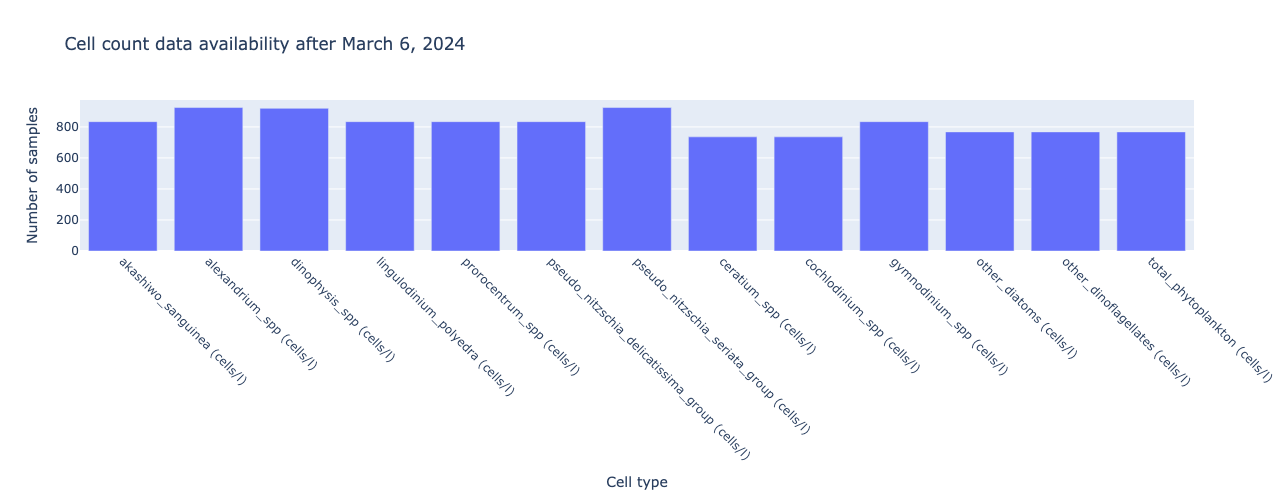

In [29]:
cell_counts = (
    df[CELL_COLS]
    .notna()
    .sum()
    .reset_index()
)
cell_counts.columns = ["cell_type", "n_samples"]

# Bar plot
fig = px.bar(
    cell_counts,
    x="cell_type",
    y="n_samples",
    title="Cell count data availability after March 6, 2024",
    labels={
        "cell_type": "Cell type",
        "n_samples": "Number of samples"
    }
)

fig.update_layout(
    xaxis_tickangle=45,
    height=500
)

fig.show()


In [52]:
!pip install --upgrade kaleido

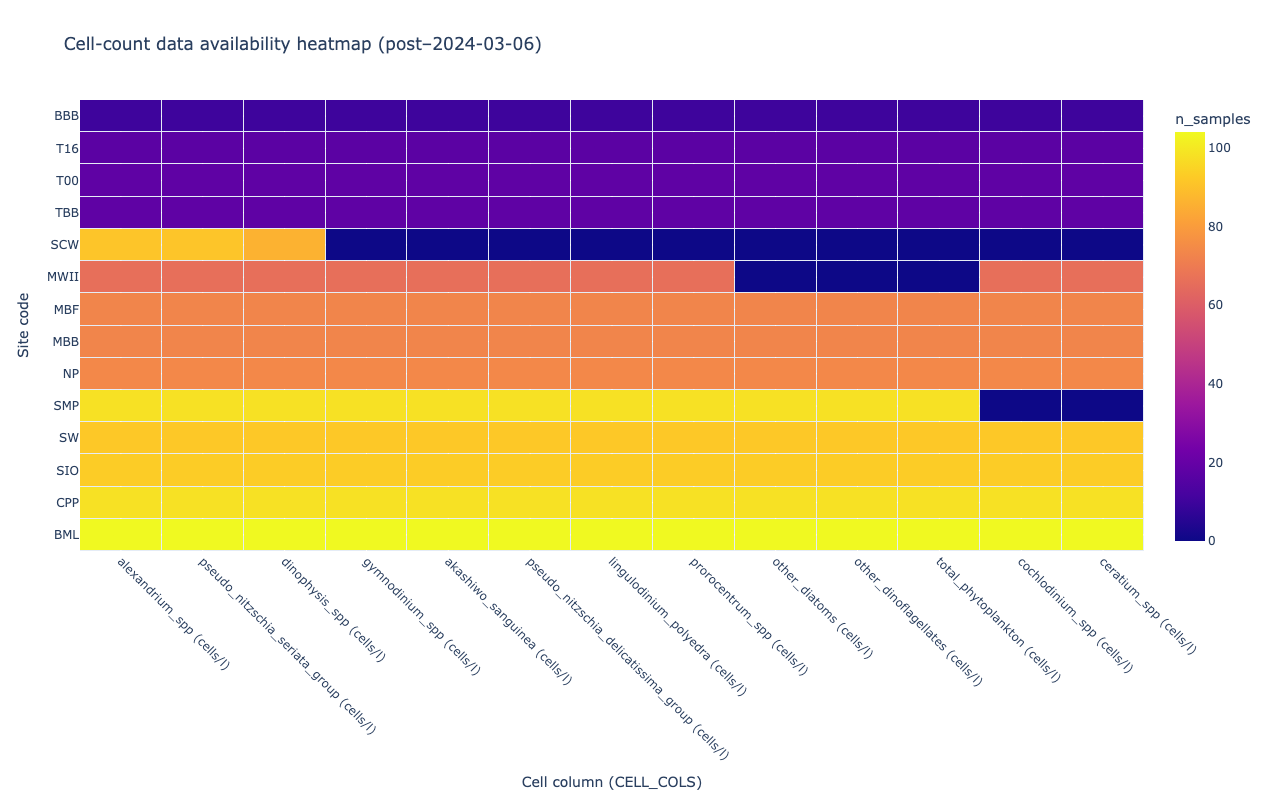

In [31]:
# --- Columns ---
site_col = "site_code"

# --- Build count matrix: non-null count per (site, cell_col) ---
counts = (
    df[[site_col] + CELL_COLS]
    .melt(id_vars=site_col, value_vars=CELL_COLS, var_name="cell_col", value_name="cells")
    .assign(has_data=lambda x: x["cells"].notna())
    .groupby([site_col, "cell_col"])["has_data"]
    .sum()
    .reset_index(name="n_samples")
)

heat = (
    counts.pivot(index=site_col, columns="cell_col", values="n_samples")
    .fillna(0)
)

# Optional: sort to make patterns clearer (comment out if you want original order)
heat = heat.loc[
    heat.sum(axis=1).sort_values(ascending=False).index,
    heat.sum(axis=0).sort_values(ascending=False).index
]

# --- Plot with visible "grid lines" via xgap/ygap ---
fig = go.Figure(
    data=go.Heatmap(
        z=heat.values,
        x=heat.columns.tolist(),
        y=heat.index.tolist(),
        colorbar=dict(title="n_samples"),
        xgap=1,   # <-- creates vertical gridlines
        ygap=1,   # <-- creates horizontal gridlines
    )
)

fig.update_layout(
    title="Cell-count data availability heatmap (post–2024-03-06)",
    height=800,
    xaxis=dict(title="Cell column (CELL_COLS)", tickangle=45),
    yaxis=dict(title="Site code"),
)

fig.show()
fig.write_image(FIG_DIR/'heatmap.pdf')

In [32]:

# Long format
long = df[["site_code"] + CELL_COLS].melt(
    id_vars="site_code",
    value_vars=CELL_COLS,
    var_name="cell_type",
    value_name="cells"
)

# Aggregate correctly
summary = (
    long
    .groupby(["site_code", "cell_type"])["cells"]
    .agg(
        n_samples_nonnull=lambda s: s.notna().sum(),   # should be constant per site
        n_samples_pos=lambda s: (s > 0).sum(),         # detections
    )
    .reset_index()
)

summary["detection_rate"] = (
    summary["n_samples_pos"] / summary["n_samples_nonnull"]
)

top_sites = df["site_code"].value_counts().head(8).index
summary = summary[summary["site_code"].isin(top_sites)]


In [33]:
summary_ = summary[summary.cell_type != "total_phytoplankton (cells/l)"]

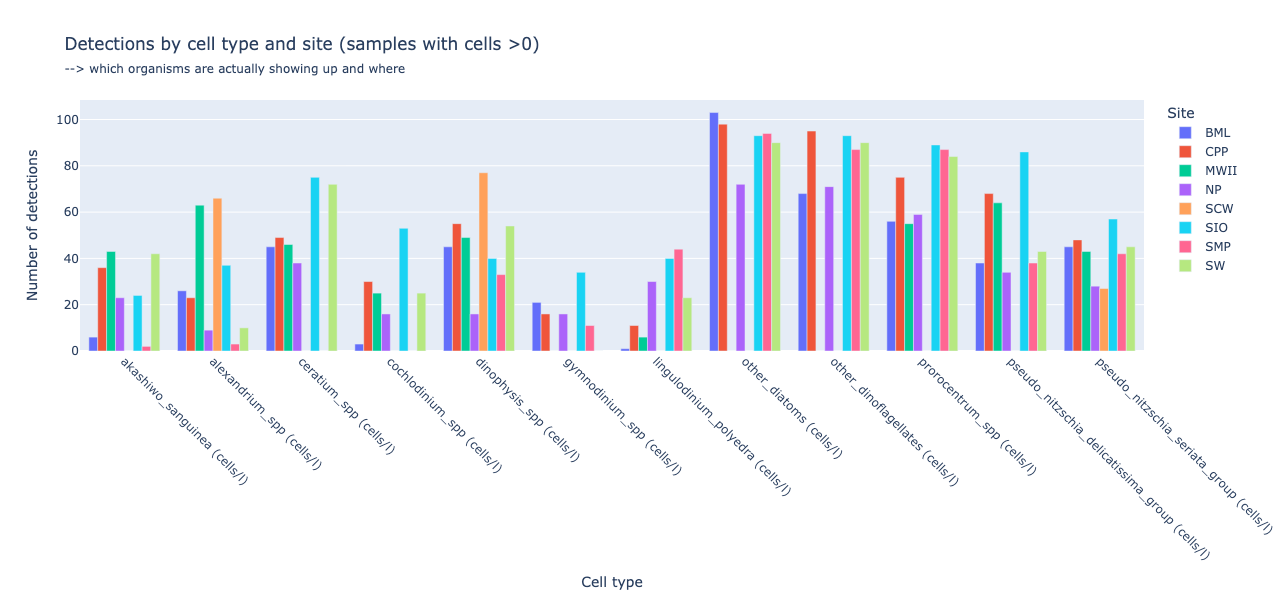

In [34]:
# Which organisms are actually showing up and where
fig_counts = px.bar(
    summary_,
    x="cell_type",
    y="n_samples_pos",
    color="site_code",
    barmode="group",
    title="Detections by cell type and site (samples with cells >0)",
    subtitle=" --> which organisms are actually showing up and where",
    labels={
        "cell_type": "Cell type",
        "n_samples_pos": "Number of detections",
        "site_code": "Site",
    },
)

fig_counts.update_layout(
    xaxis_tickangle=45,
    height=600,
)

fig_counts.show()

fig_counts.write_image(FIG_DIR / 'who_where.pdf')
fig_counts.write_image(FIG_DIR / 'who_where.png')

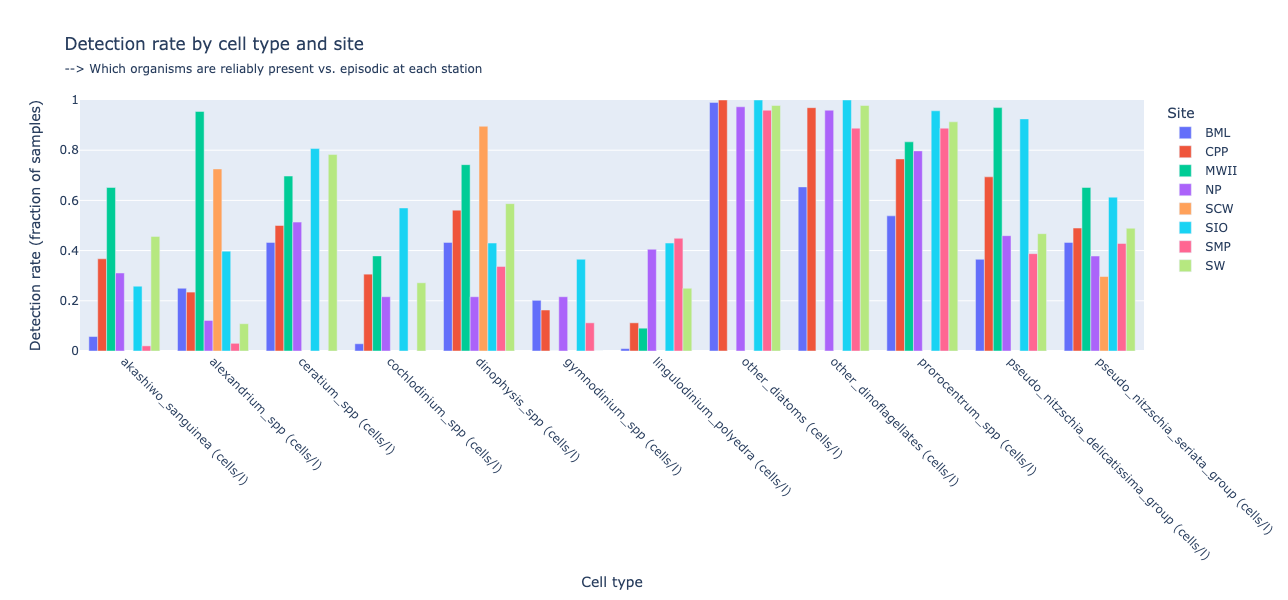

In [35]:
fig_rate = px.bar(
    summary_,
    x="cell_type",
    y="detection_rate",
    color="site_code",
    barmode="group",
    title="Detection rate by cell type and site",
    subtitle=" --> Which organisms are reliably present vs. episodic at each station",
    labels={
        "cell_type": "Cell type",
        "detection_rate": "Detection rate (fraction of samples)",
        "site_code": "Site",
    },
)

fig_rate.update_layout(
    xaxis_tickangle=45,
    height=600,
    yaxis=dict(range=[0, 1]),
)

fig_rate.show()
fig_rate.write_image(FIG_DIR / 'who_rate.pdf')
fig_rate.write_image(FIG_DIR / 'who_rate.png')

$\rightarrow$ SIO, CPP, MW most promising sites

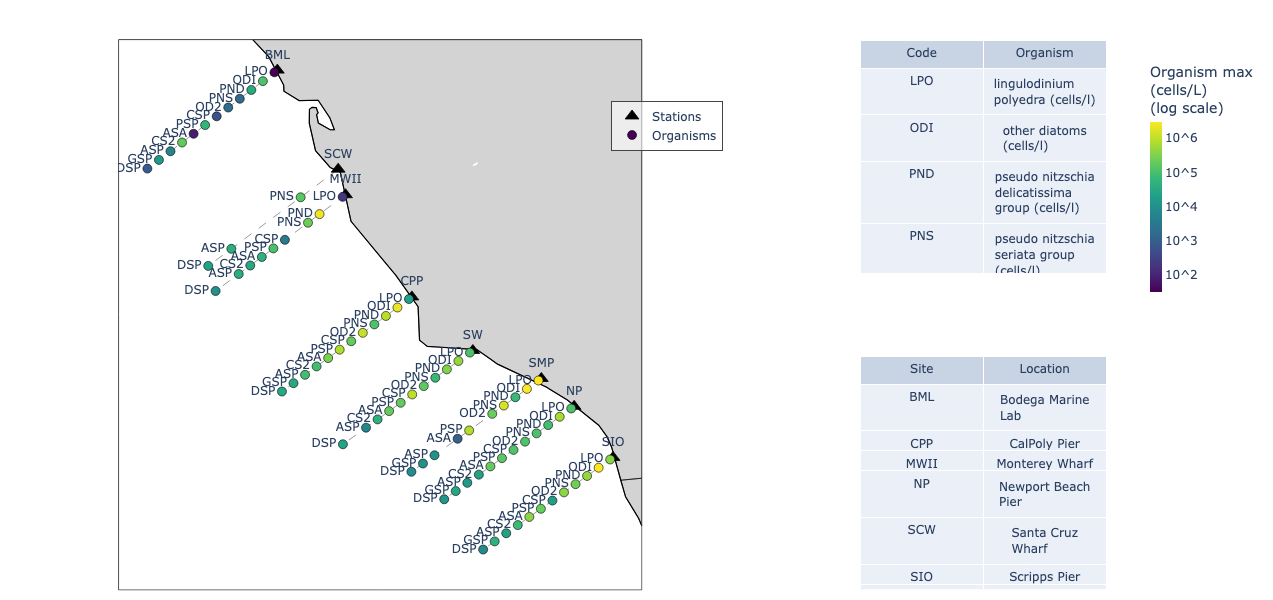

In [42]:
# ============================================================
# Stations = dark triangles (no TOTAL encoding); circles = organism maxima (log10 colorbar)
# (Assumes: df exists, CELL_COLS exists, and you've already imported numpy as np,
#  plotly.graph_objects as go, and make_subplots)
# ============================================================

# ---- columns ----
TOTAL_COL = "total_phytoplankton (cells/l)"
ORG_CELL_COLS = [c for c in CELL_COLS if c != TOTAL_COL]  # exclude TOTAL completely

TOP_N_ORGANISMS = 12
# ---- limit to top N sites (by number of rows / samples in df) ----
TOP_N_SITES = 8
top_sites = df["site_code"].value_counts().head(TOP_N_SITES).index
df = df[df["site_code"].isin(top_sites)].copy()


overall_max = df[ORG_CELL_COLS].max(axis=0, skipna=True).sort_values(ascending=False)
org_cols = overall_max.head(TOP_N_ORGANISMS).index.tolist()

# ---- organism codes ----
def make_3letter_codes(cols):
    used, out = set(), {}
    for c in cols:
        base = c.replace("_cells_l", "")
        toks = [t for t in base.replace("-", "_").split("_") if t]
        if len(toks) >= 3:
            code = (toks[0][0] + toks[1][0] + toks[2][0]).upper()
        elif len(toks) == 2:
            code = (toks[0][0] + toks[1][:2]).upper()
        else:
            code = toks[0][:3].upper()
        code = (code + "XXX")[:3]
        if code in used:
            k = 2
            while f"{code[:2]}{k}" in used:
                k += 1
            code = f"{code[:2]}{k}"
        used.add(code)
        out[c] = code
    return out

ORG_CODE = make_3letter_codes(org_cols)

def clean_org_name(c):
    return c.replace("_cells_l", "").replace("_", " ")

# ---- site coords (station locations only) ----
site_xy = (
    df.groupby("site_code")
      .agg(lat=("lat", "median"), lon=("lon", "median"))
      .reset_index()
      .dropna(subset=["lat", "lon"])
)

# ---- per-site organism maxima for circles ----
site_max = df.groupby("site_code")[org_cols].max()
site_max = site_xy.set_index("site_code").join(site_max, how="inner").reset_index()

long = (
    site_max.melt(
        id_vars=["site_code", "lat", "lon"],
        value_vars=org_cols,
        var_name="organism_col",
        value_name="max_cells",
    )
    .dropna(subset=["max_cells"])
)

# geometry (SW offshore line)
base_lon, base_lat = 0.05, 0.03
step_lon, step_lat = 0.20, 0.12
order = {c: i for i, c in enumerate(org_cols)}
long["slot"] = long["organism_col"].map(order)
long["lon_o"] = long["lon"] - base_lon - long["slot"] * step_lon
long["lat_o"] = long["lat"] - base_lat - long["slot"] * step_lat
long["code"] = long["organism_col"].map(ORG_CODE)

# log color scaling for circles
long = long[long["max_cells"] > 0].copy()
long["log10_max"] = np.log10(long["max_cells"])

zmin, zmax = long["log10_max"].min(), long["log10_max"].max()
z_ticks = np.arange(np.floor(zmin), np.ceil(zmax) + 1)
z_tick_text = [f"10^{int(t)}" for t in z_ticks]

# ---- dashed connector lines (one per site) ----
line_traces = []
for site, g in long.groupby("site_code"):
    g = g.sort_values("slot")
    xs = [g["lon"].iloc[0]] + g["lon_o"].tolist()
    ys = [g["lat"].iloc[0]] + g["lat_o"].tolist()
    line_traces.append(
        go.Scattergeo(
            lon=xs, lat=ys,
            mode="lines",
            line=dict(width=1, dash="dash", color="rgba(0,0,0,0.4)"),
            showlegend=False,
            hoverinfo="skip",
        )
    )

# ---- station triangles: dark, equal size ----
station_trace = go.Scattergeo(
    lon=site_xy["lon"], lat=site_xy["lat"],
    mode="markers+text",
    marker=dict(
        symbol="triangle-up",
        size=12,
        color="black",
        line=dict(width=0.8, color="black"),
    ),
    text=site_xy["site_code"],
    textposition="top center",
    name="Stations",
)

# ---- organism circles ----
circle_trace = go.Scattergeo(
    lon=long["lon_o"], lat=long["lat_o"],
    mode="markers+text",
    marker=dict(
        size=9,
        color=long["log10_max"],
        colorscale="Viridis",
        cmin=zmin, cmax=zmax,
        colorbar=dict(
            title="Organism max<br>(cells/L)<br>(log scale)",
            tickvals=z_ticks,
            ticktext=z_tick_text,
            len=0.45,
            y=0.75,
            x=1.03,
            thickness=12,
        ),
        line=dict(width=0.6, color="black"),
    ),
    text=long["code"],
    textposition="middle left",
    name="Organisms",

    # --- ADD THIS ---
    customdata=np.stack(
        [
            long["site_code"].to_numpy(),
            long["organism_col"].to_numpy(),
            long["max_cells"].to_numpy(),
        ],
        axis=1
    ),
    hovertemplate=(
        "site=%{customdata[0]}<br>"
        "organism=%{customdata[1]}<br>"
        "max_cells=%{customdata[2]:.3g} cells/L"
        "<extra></extra>"
    ),
    # ---------------
)

# ---- tables ----
org_table = [[ORG_CODE[c], clean_org_name(c)] for c in org_cols]
name_col = "location_name" if "location_name" in df.columns else "site_name"
site_lookup = (
    df.groupby("site_code")[name_col]
      .agg(lambda s: s.mode().iloc[0])
      .reset_index()
      .values.tolist()
)



fig = make_subplots(
    rows=2, cols=2,
    column_widths=[0.75, 0.25],
    row_heights=[0.5, 0.5],
    specs=[[{"type": "scattergeo", "rowspan": 2}, {"type": "table"}],
           [None, {"type": "table"}]],
)

# ---- figure layout ----
#fig = make_subplots(
#    rows=2, cols=2,
#    column_widths=[0.72, 0.28],
#    row_heights=[0.5, 0.5],
#    specs=[[{"type": "scattergeo", "rowspan": 2}, {"type": "table"}],
#           [None, {"type": "table"}]],
#)

for t in line_traces:
    fig.add_trace(t, row=1, col=1)

fig.add_trace(station_trace, row=1, col=1)
fig.add_trace(circle_trace, row=1, col=1)

fig.add_trace(
    go.Table(
        header=dict(values=["Code", "Organism"]),
        cells=dict(values=list(map(list, zip(*org_table)))),
    ),
    row=1, col=2
)

fig.add_trace(
    go.Table(
        header=dict(values=["Site", "Location"]),
        cells=dict(values=list(map(list, zip(*site_lookup)))),
    ),
    row=2, col=2
)

# ---- geo framing (focused extent + higher-res) ----
lat_min = min(site_xy["lat"].min(), long["lat_o"].min()) - 0.5
lat_max = max(site_xy["lat"].max(), long["lat_o"].max()) + 0.5
lon_min = min(site_xy["lon"].min(), long["lon_o"].min()) - 0.5
lon_max = max(site_xy["lon"].max(), long["lon_o"].max()) + 0.5

fig.update_geos(
    projection_type="mercator",
    resolution=50,
    showland=True, landcolor="lightgray",
    showocean=True, oceancolor="white",
    showcoastlines=True, coastlinecolor="black", coastlinewidth=1.2,
    showcountries=True, countrycolor="black", countrywidth=0.6,
    showlakes=True, lakecolor="white",
    lataxis_range=[lat_min, lat_max],
    lonaxis_range=[lon_min, lon_max],
)
fig.update_layout(
    width=1000,
    height=600,
    margin=dict(l=10, r=40, t=40, b=10)
)
#fig.update_layout(
#    height=800,
#    title="Stations (triangles) + organism maxima (circles)",
#    margin=dict(l=10, r=130, t=40, b=10),
#)
fig.update_layout(
    legend=dict(
        x=0.65,          # <-- move legend left (was ~0.6–0.99)
        y=0.89,
        xanchor="right",
        yanchor="top",
        bgcolor="rgba(255,255,255,0.6)",
        borderwidth=1,
    ),
)

fig.show()
fig.write_image(FIG_DIR/'map.pdf')
fig.write_image(FIG_DIR/'map.png')

### Breakdown of phytogroup:
$\rightarrow$ Why this matters for PACE

PACE OCI retrievals are much more sensitive to groups than species:

* Diatoms ↔ silica, backscattering
* Dinoflagellates ↔ absorption shape, pigments
* Cyanobacteria ↔ phycocyanin / phycoerythrin
* Haptophytes ↔ calcite scattering

$\rightarrow$ So grouping allows:

* aggregate cell counts by group
* test group-level SCMs
* reduce label noise in satellite matchups

In [43]:
long.head()

,site_code,lat,lon,organism_col,max_cells,slot,lon_o,lat_o,code,log10_max
0,BML,38.316130,-123.070500,lingulodinium_polyedra (cells/l),32.000,0,-123.120500,38.286130,LPO,1.505150
1,CPP,35.170204,-120.740685,lingulodinium_polyedra (cells/l),21323.068,0,-120.790685,35.140204,LPO,4.328850
2,MWII,36.603683,-121.889275,lingulodinium_polyedra (cells/l),200.000,0,-121.939275,36.573683,LPO,2.301030
3,NP,33.606100,-117.931100,lingulodinium_polyedra (cells/l),109148.000,0,-117.981100,33.576100,LPO,5.038016
5,SIO,32.867000,-117.257000,lingulodinium_polyedra (cells/l),380487.000,0,-117.307000,32.837000,LPO,5.580340


In [44]:
long.organism_col.value_counts(normalize=True).round(4)*100

organism_col
pseudo_nitzschia_seriata_group (cells/l)          9.88
dinophysis_spp (cells/l)                          9.88
alexandrium_spp (cells/l)                         9.88
lingulodinium_polyedra (cells/l)                  8.64
akashiwo_sanguinea (cells/l)                      8.64
pseudo_nitzschia_delicatissima_group (cells/l)    8.64
prorocentrum_spp (cells/l)                        8.64
other_diatoms (cells/l)                           7.41
other_dinoflagellates (cells/l)                   7.41
cochlodinium_spp (cells/l)                        7.41
ceratium_spp (cells/l)                            7.41
gymnodinium_spp (cells/l)                         6.17
Name: proportion, dtype: float64

In [45]:
PHYTO_GROUP = {
    # --- Diatoms ---
    "pseudo_nitzschia_seriata_group (cells/l)": "diatom",
    "pseudo_nitzschia_delicatissima_group (cells/l)": "diatom",
    "other_diatoms (cells/l)": "diatom",

    # --- Dinoflagellates ---
    "prorocentrum_spp (cells/l)": "dinoflagellate",
    "dinophysis_spp (cells/l)": "dinoflagellate",
    "akashiwo_sanguinea (cells/l)": "dinoflagellate",
    "ceratium_spp (cells/l)": "dinoflagellate",
    "gymnodinium_spp (cells/l)": "dinoflagellate",
    "alexandrium_spp (cells/l)": "dinoflagellate",
    "cochlodinium_spp (cells/l)l": "dinoflagellate",
    "lingulodinium_polyedra (cells/l)": "dinoflagellate",
    "other_dinoflagellates (cells/l)": "dinoflagellate",
}
# 1) Map organism 
long["phyto_group"] = long["organism_col"].map(PHYTO_GROUP)


In [46]:
long.head()

,site_code,lat,lon,organism_col,max_cells,slot,lon_o,lat_o,code,log10_max,phyto_group
0,BML,38.316130,-123.070500,lingulodinium_polyedra (cells/l),32.000,0,-123.120500,38.286130,LPO,1.505150,dinoflagellate
1,CPP,35.170204,-120.740685,lingulodinium_polyedra (cells/l),21323.068,0,-120.790685,35.140204,LPO,4.328850,dinoflagellate
2,MWII,36.603683,-121.889275,lingulodinium_polyedra (cells/l),200.000,0,-121.939275,36.573683,LPO,2.301030,dinoflagellate
3,NP,33.606100,-117.931100,lingulodinium_polyedra (cells/l),109148.000,0,-117.981100,33.576100,LPO,5.038016,dinoflagellate
5,SIO,32.867000,-117.257000,lingulodinium_polyedra (cells/l),380487.000,0,-117.307000,32.837000,LPO,5.580340,dinoflagellate


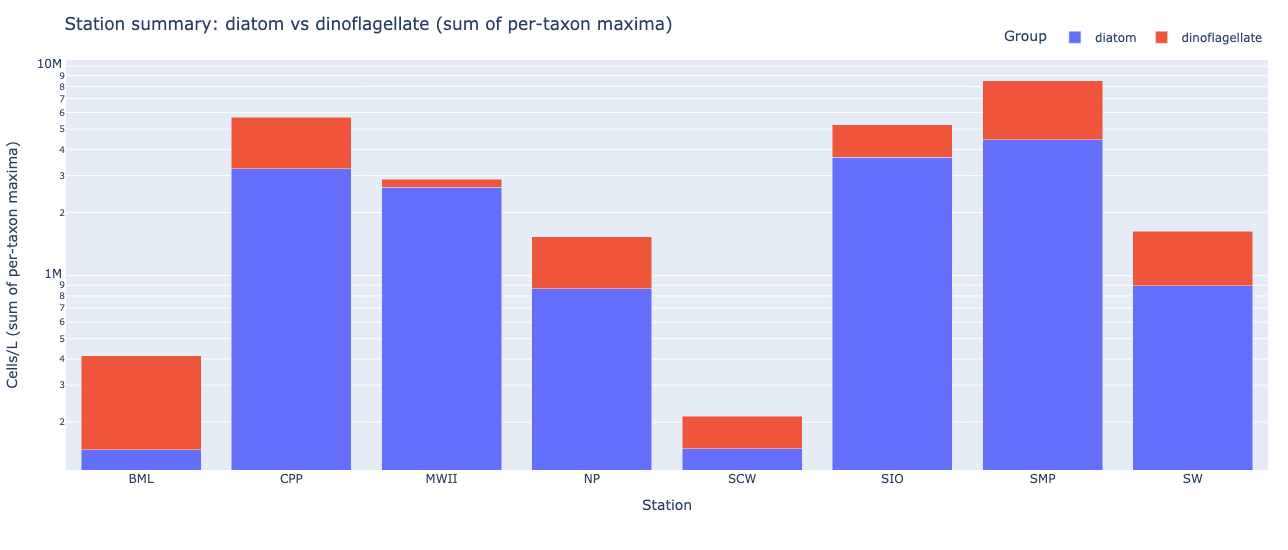

In [47]:

# 2) Aggregate: site × group
plot_long = long.dropna(subset=["phyto_group"]).copy()
site_group = (
    plot_long
    .groupby(["site_code", "phyto_group"], as_index=False)["max_cells"]
    .sum()
)

# 3) Order sites by total (so the plot reads well)
site_totals = site_group.groupby("site_code", as_index=False)["max_cells"].sum()
site_order = site_totals.sort_values("max_cells", ascending=False)["site_code"].tolist()
site_group["site_code"] = pd.Categorical(site_group["site_code"], categories=site_order, ordered=True)

# 4) Stacked bar (log y is useful for cell counts)
fig = px.bar(
    site_group,
    x="site_code",
    y="max_cells",
    color="phyto_group",
    barmode="stack",
    title="Station summary: diatom vs dinoflagellate (sum of per-taxon maxima)",
    labels={"site_code": "Station", "max_cells": "Cells/L (sum of per-taxon maxima)", "phyto_group": "Group"},
)

fig.update_yaxes(type="log")  # comment out if you want linear scale
fig.update_layout(
    height=550,
    margin=dict(l=40, r=20, t=60, b=80),
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
)

# Better hover
fig.update_traces(
    hovertemplate="Station=%{x}<br>Group=%{legendgroup}<br>Cells/L=%{y:.3g}<extra></extra>"
)

fig.show()

/tmp/ipykernel_2324/3365652031.py:1: FutureWarning:

The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior



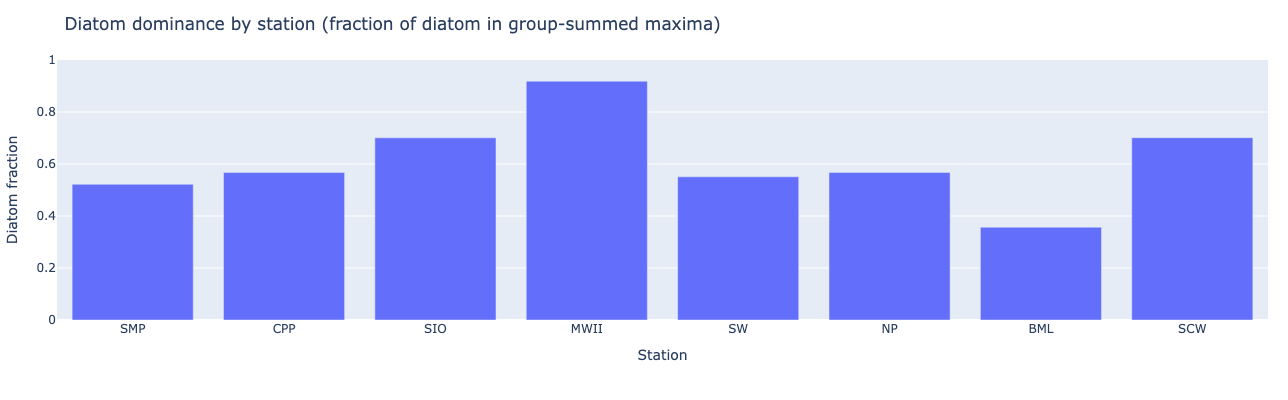

In [48]:
pivot = site_group.pivot_table(index="site_code", columns="phyto_group", values="max_cells", aggfunc="sum").fillna(0)
pivot["total"] = pivot.sum(axis=1)
pivot["diatom_frac"] = np.where(pivot["total"] > 0, pivot.get("diatom", 0) / pivot["total"], np.nan)

dom = pivot.reset_index()[["site_code", "diatom_frac"]]
dom["site_code"] = pd.Categorical(dom["site_code"], categories=site_order, ordered=True)

fig2 = px.bar(
    dom,
    x="site_code",
    y="diatom_frac",
    title="Diatom dominance by station (fraction of diatom in group-summed maxima)",
    labels={"site_code": "Station", "diatom_frac": "Diatom fraction"},
)
fig2.update_yaxes(range=[0, 1])
fig2.update_layout(height=400, margin=dict(l=40, r=20, t=60, b=80))
fig2.show()


/tmp/ipykernel_25855/2895859677.py:1: FutureWarning:

The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior



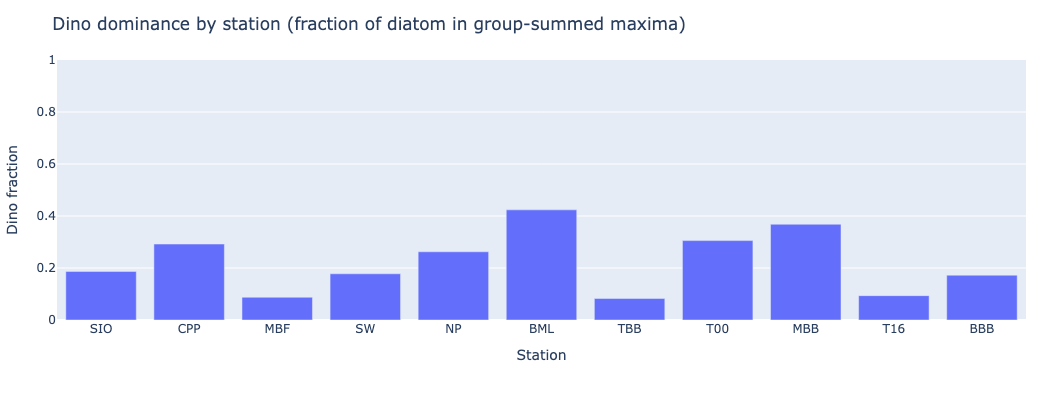

In [40]:
pivot = site_group.pivot_table(index="site_code", columns="phyto_group", values="max_cells", aggfunc="sum").fillna(0)
pivot["total"] = pivot.sum(axis=1)
pivot["dino_frac"] = np.where(pivot["total"] > 0, pivot.get("dinoflagellate", 0) / pivot["total"], np.nan)

dom = pivot.reset_index()[["site_code", "dino_frac"]]
dom["site_code"] = pd.Categorical(dom["site_code"], categories=site_order, ordered=True)

fig2 = px.bar(
    dom,
    x="site_code",
    y="dino_frac",
    title="Dino dominance by station (fraction of diatom in group-summed maxima)",
    labels={"site_code": "Station", "dino_frac": "Dino fraction"},
)
fig2.update_yaxes(range=[0, 1])
fig2.update_layout(height=400, margin=dict(l=40, r=20, t=60, b=80))
fig2.show()

### Mathchup Input

In [45]:
# drop rows without time or coordinates (cannot be matched)
time_col = 'time_utc'
df_m = df.dropna(subset=["site_code", "lat", "lon", time_col]).copy()

station_matchups = (
    df_m
    .groupby("site_code")
    .agg(
        lat=("lat", "median"),
        lon=("lon", "median"),
        times=(time_col, lambda s: sorted(s.unique())),
        n_samples=(time_col, "nunique"),
        t_start=(time_col, "min"),
        t_end=(time_col, "max"),
    )
    .reset_index()
)

In [46]:
# Per-station lat/lon lookup
station_coords = (
    station_matchups
    .set_index("site_code")[["lat", "lon"]]
    .to_dict(orient="index")
)
station_coords

{'BBB': {'lat': 38.3126, 'lon': -123.0825},
 'BML': {'lat': 38.31613, 'lon': -123.0705},
 'CPP': {'lat': 35.170204, 'lon': -120.740685},
 'MBB': {'lat': 35.32999, 'lon': -120.844475},
 'MBF': {'lat': 35.370853, 'lon': -120.858734},
 'NP': {'lat': 33.6061, 'lon': -117.9311},
 'SIO': {'lat': 32.867, 'lon': -117.257},
 'SW': {'lat': 34.408043, 'lon': -119.68485},
 'T00': {'lat': 38.23082, 'lon': -122.9791},
 'T16': {'lat': 38.11798, 'lon': -122.867},
 'TBB': {'lat': 38.18967, 'lon': -122.9286}}

In [47]:
station_matchups.head()

,site_code,lat,lon,times,n_samples,t_start,t_end
0,BBB,38.312600,-123.082500,"[2024-03-18 19:50:00+00:00, 2024-05-16 18:30:0...",10,2024-03-18 19:50:00+00:00,2025-10-29 18:12:00+00:00
1,BML,38.316130,-123.070500,"[2024-03-11 16:50:00+00:00, 2024-03-18 19:00:0...",104,2024-03-11 16:50:00+00:00,2025-12-15 21:26:00+00:00
2,CPP,35.170204,-120.740685,"[2024-03-11 16:00:00+00:00, 2024-03-17 16:00:0...",98,2024-03-11 16:00:00+00:00,2026-01-19 17:43:00+00:00
3,MBB,35.329990,-120.844475,"[2024-03-11 18:25:00+00:00, 2024-03-18 14:00:0...",73,2024-03-11 18:25:00+00:00,2025-08-05 17:23:00+00:00
4,MBF,35.370853,-120.858734,"[2024-03-11 17:40:00+00:00, 2024-03-18 13:30:0...",73,2024-03-11 17:40:00+00:00,2025-08-05 16:40:00+00:00


In [48]:
lookup_station_times = (
    station_matchups
    .set_index("site_code")["times"]
    .to_dict()
)
lookup_station_times['SIO']

[Timestamp('2024-03-11 19:15:00+0000', tz='UTC'),
 Timestamp('2024-03-18 19:00:00+0000', tz='UTC'),
 Timestamp('2024-03-25 19:34:00+0000', tz='UTC'),
 Timestamp('2024-04-01 19:27:00+0000', tz='UTC'),
 Timestamp('2024-04-08 19:53:00+0000', tz='UTC'),
 Timestamp('2024-04-15 18:58:00+0000', tz='UTC'),
 Timestamp('2024-04-22 18:56:00+0000', tz='UTC'),
 Timestamp('2024-04-29 19:41:00+0000', tz='UTC'),
 Timestamp('2024-05-06 19:10:00+0000', tz='UTC'),
 Timestamp('2024-05-13 18:31:00+0000', tz='UTC'),
 Timestamp('2024-05-20 18:51:00+0000', tz='UTC'),
 Timestamp('2024-05-28 19:21:00+0000', tz='UTC'),
 Timestamp('2024-06-03 19:18:00+0000', tz='UTC'),
 Timestamp('2024-06-10 19:00:00+0000', tz='UTC'),
 Timestamp('2024-06-17 19:19:00+0000', tz='UTC'),
 Timestamp('2024-06-24 19:09:00+0000', tz='UTC'),
 Timestamp('2024-07-01 19:21:00+0000', tz='UTC'),
 Timestamp('2024-07-08 18:16:00+0000', tz='UTC'),
 Timestamp('2024-07-15 19:23:00+0000', tz='UTC'),
 Timestamp('2024-07-22 19:02:00+0000', tz='UTC'),


In [50]:
# organism columns that we know how to group
groupable_cols = [c for c in ORG_CELL_COLS if c in PHYTO_GROUP]

# melt raw df to (station, time, organism, cells)
tidy = (
    df[["site_code", time_col] + groupable_cols]
    .melt(
        id_vars=["site_code", time_col],
        value_vars=groupable_cols,
        var_name="organism_col",
        value_name="cells",
    )
    .dropna(subset=["cells"])
)

# map organism -> group
tidy["phyto_group"] = tidy["organism_col"].map(PHYTO_GROUP)

# keep only positive counts
tidy = tidy[tidy["cells"] >= 0]

In [51]:
lookup_station_group_df = (
    tidy
    .groupby(["site_code", "phyto_group"])[time_col]
    .apply(lambda s: sorted(s.unique()))
    .reset_index()
)

In [52]:
lookup_station_group_time = defaultdict(dict)

for _, row in lookup_station_group_df.iterrows():
    lookup_station_group_time[row["site_code"]][row["phyto_group"]] = row[time_col]

In [53]:
lookup_station_group_time['SIO']['dinoflagellate']

[Timestamp('2024-03-11 19:15:00+0000', tz='UTC'),
 Timestamp('2024-03-18 19:00:00+0000', tz='UTC'),
 Timestamp('2024-03-25 19:34:00+0000', tz='UTC'),
 Timestamp('2024-04-01 19:27:00+0000', tz='UTC'),
 Timestamp('2024-04-08 19:53:00+0000', tz='UTC'),
 Timestamp('2024-04-15 18:58:00+0000', tz='UTC'),
 Timestamp('2024-04-22 18:56:00+0000', tz='UTC'),
 Timestamp('2024-04-29 19:41:00+0000', tz='UTC'),
 Timestamp('2024-05-06 19:10:00+0000', tz='UTC'),
 Timestamp('2024-05-13 18:31:00+0000', tz='UTC'),
 Timestamp('2024-05-20 18:51:00+0000', tz='UTC'),
 Timestamp('2024-05-28 19:21:00+0000', tz='UTC'),
 Timestamp('2024-06-03 19:18:00+0000', tz='UTC'),
 Timestamp('2024-06-10 19:00:00+0000', tz='UTC'),
 Timestamp('2024-06-17 19:19:00+0000', tz='UTC'),
 Timestamp('2024-06-24 19:09:00+0000', tz='UTC'),
 Timestamp('2024-07-01 19:21:00+0000', tz='UTC'),
 Timestamp('2024-07-08 18:16:00+0000', tz='UTC'),
 Timestamp('2024-07-15 19:23:00+0000', tz='UTC'),
 Timestamp('2024-07-22 19:02:00+0000', tz='UTC'),


In [54]:
lookup_station_group_time['SIO']['diatom']

[Timestamp('2024-03-11 19:15:00+0000', tz='UTC'),
 Timestamp('2024-03-18 19:00:00+0000', tz='UTC'),
 Timestamp('2024-03-25 19:34:00+0000', tz='UTC'),
 Timestamp('2024-04-01 19:27:00+0000', tz='UTC'),
 Timestamp('2024-04-08 19:53:00+0000', tz='UTC'),
 Timestamp('2024-04-15 18:58:00+0000', tz='UTC'),
 Timestamp('2024-04-22 18:56:00+0000', tz='UTC'),
 Timestamp('2024-04-29 19:41:00+0000', tz='UTC'),
 Timestamp('2024-05-06 19:10:00+0000', tz='UTC'),
 Timestamp('2024-05-13 18:31:00+0000', tz='UTC'),
 Timestamp('2024-05-20 18:51:00+0000', tz='UTC'),
 Timestamp('2024-05-28 19:21:00+0000', tz='UTC'),
 Timestamp('2024-06-03 19:18:00+0000', tz='UTC'),
 Timestamp('2024-06-10 19:00:00+0000', tz='UTC'),
 Timestamp('2024-06-17 19:19:00+0000', tz='UTC'),
 Timestamp('2024-06-24 19:09:00+0000', tz='UTC'),
 Timestamp('2024-07-01 19:21:00+0000', tz='UTC'),
 Timestamp('2024-07-08 18:16:00+0000', tz='UTC'),
 Timestamp('2024-07-15 19:23:00+0000', tz='UTC'),
 Timestamp('2024-07-22 19:02:00+0000', tz='UTC'),


In [58]:

# Tidy to (site, time, organism_col, cells)
tidy = (
    df[["site_code", time_col] + ORG_CELL_COLS]
    .melt(
        id_vars=["site_code", time_col],
        value_vars=ORG_CELL_COLS,
        var_name="organism_col",
        value_name="cells",
    )
    .dropna(subset=["site_code", time_col, "cells"])
)

# Keep only positive counts
tidy = tidy[tidy["cells"] >= 0]

# Aggregate to unique times per (site, organism)
lookup_df = (
    tidy.groupby(["site_code", "organism_col"])[time_col]
        .apply(lambda s: sorted(s.unique()))
        .reset_index()
)

# Nested dict: lookup[site][organism] -> times
lookup_station_organism_time = defaultdict(dict)
for _, row in lookup_df.iterrows():
    lookup_station_organism_time[row["site_code"]][row["organism_col"]] = row[time_col]

# (optional) convert to plain dict
#lookup = {k: dict(v) for k, v in lookup.items()}

In [60]:
lookup_station_organism_time['SIO']['pseudo_nitzschia_delicatissima_group (cells/l)']

[Timestamp('2024-03-11 19:15:00+0000', tz='UTC'),
 Timestamp('2024-03-18 19:00:00+0000', tz='UTC'),
 Timestamp('2024-03-25 19:34:00+0000', tz='UTC'),
 Timestamp('2024-04-01 19:27:00+0000', tz='UTC'),
 Timestamp('2024-04-08 19:53:00+0000', tz='UTC'),
 Timestamp('2024-04-15 18:58:00+0000', tz='UTC'),
 Timestamp('2024-04-22 18:56:00+0000', tz='UTC'),
 Timestamp('2024-04-29 19:41:00+0000', tz='UTC'),
 Timestamp('2024-05-06 19:10:00+0000', tz='UTC'),
 Timestamp('2024-05-13 18:31:00+0000', tz='UTC'),
 Timestamp('2024-05-20 18:51:00+0000', tz='UTC'),
 Timestamp('2024-05-28 19:21:00+0000', tz='UTC'),
 Timestamp('2024-06-03 19:18:00+0000', tz='UTC'),
 Timestamp('2024-06-10 19:00:00+0000', tz='UTC'),
 Timestamp('2024-06-17 19:19:00+0000', tz='UTC'),
 Timestamp('2024-06-24 19:09:00+0000', tz='UTC'),
 Timestamp('2024-07-01 19:21:00+0000', tz='UTC'),
 Timestamp('2024-07-08 18:16:00+0000', tz='UTC'),
 Timestamp('2024-07-15 19:23:00+0000', tz='UTC'),
 Timestamp('2024-07-22 19:02:00+0000', tz='UTC'),


In [62]:
import pickle

with open(DATA_DIR / "lookup_station_times.pkl", "wb") as f:
    pickle.dump(lookup_station_times, f)

with open(DATA_DIR / "lookup_station_group_times.pkl", "wb") as f:
    pickle.dump(lookup_station_group_time, f)

with open(DATA_DIR / "lookup_station_organism_times.pkl", "wb") as f:
    pickle.dump(lookup_station_organism_time, f)
with open(DATA_DIR / "station_coords.pkl", "wb") as f:
    pickle.dump(station_coords, f)
